# Homework 6: Assessing Models and Testing Hypotheses

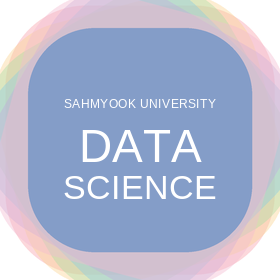

Please complete this notebook by filling in the cells provided. Before you begin, execute the previous cell to load the provided tests.

**Helpful Resource:**
- [Python Reference](http://data8.org/sp26/reference/): Cheat sheet of helpful array & table methods used in this data science course!

**Recommended Readings**: 
* [Sampling and Empirical Distributions](https://www.inferentialthinking.com/chapters/10/Sampling_and_Empirical_Distributions.html)
* [Testing Hypotheses](https://www.inferentialthinking.com/chapters/11/Testing_Hypotheses.html)
* [A/B Testing](https://inferentialthinking.com/chapters/12/1/AB_Testing.html)

In [ ]:
# Setup (run this first!)
!pip install -q otter-grader datascience
!git clone https://github.com/jihyungkim94/datascience.git 2>/dev/null || true
import os, json
os.chdir('/content/datascience/hw/hw06')
os.makedirs('tests', exist_ok=True)
with open('hw06.ipynb') as _f:
    _nb = json.load(_f)
for _name, _test in _nb['metadata']['otter']['tests'].items():
    with open('tests/' + _name + '.py', 'w') as _f:
        _f.write('OK_FORMAT = True\n\ntest = ' + repr(_test) + '\n')
import otter
grader = otter.Notebook('hw06.ipynb')
print('Ready! (30 tests loaded)')

Please complete this notebook by filling in the cells provided. **Before you begin, execute the cell below to setup the notebook by importing some helpful libraries.** Each time you start your server, you will need to execute this cell again.

For all problems that you must write explanations and sentences for, you **must** provide your answer in the designated space. Moreover, throughout this homework and all future ones, **please be sure to not re-assign variables throughout the notebook!** For example, if you use `max_temperature` in your answer to one question, do not reassign it later on. Otherwise, you will fail tests that you thought you were passing previously!

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged.

You should start early so that you have time to get help if you're stuck.

---

The point breakdown for this assignment is given in the table below:
| Category | Points |
| --- | --- |
| Autograder (Coding questions) | 96 |
| Written (Visualization questions) | 4 |
| **Total** | 100 |

In [ ]:
# Run this cell to set up the notebook, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 1. Assessing Jade's Models

Before you begin, [Section 10.4](https://inferentialthinking.com/chapters/10/4/Random_Sampling_in_Python.html) of the textbook is a useful reference for this part.

### Games with Jade
Our friend Jade comes over and asks us to play a game with her. The game works like this: 

> We will draw randomly with replacement from a simplified 13 card deck with 4 face cards (A, J, Q, K), and 9 numbered cards (2, 3, 4, 5, 6, 7, 8, 9, 10). Suppose we draw cards with replacement 13 times. If the number of face cards is greater than or equal to 4, we lose.
> 
> Otherwise, Jade loses.

We play the game once and we lose, observing 8 total face cards. We are angry and accuse Jade of cheating! Jade is adamant, however, that the deck is fair.

Jade's model claims that there is an equal chance of getting any of the cards (A, 2, 3, 4, 5, 6, 7, 8, 9, 10, J, Q, K), but we do not believe her. We believe that the deck is clearly rigged, with face cards (A, J, Q, K) being more likely than the numbered cards (2, 3, 4, 5, 6, 7, 8, 9, 10).

---

**Question 1.1.** Assign `deck_model_probabilities` to a two-item array containing the chance of drawing a face card as the first element, and the chance of drawing a numbered card as the second element under Jade's model. Since we're working with probabilities, make sure your values are between 0 and 1. **(3 Points)**


In [ ]:
deck_model_probabilities = ...
deck_model_probabilities

In [ ]:
grader.check("q1_1")

--- 

**Question 1.2.** We believe Jade's model is incorrect. In particular, we believe there to be a *larger* chance of getting a face card. Which of the following statistics can we use during our simulation to test between the model and our alternative? Assign `statistic_choice` to the correct answer. **(3 Points)**

1. The distance (absolute value) between the actual number of face cards in 13 draws and 4, the expected number of face cards in 13 draws
2. The expected number of face cards in 13 draws
3. The number of face cards we get in 13 draws


In [ ]:
statistic_choice = ...
statistic_choice

In [ ]:
grader.check("q1_2")

---

**Question 1.3.** Define the function `deck_simulation_and_statistic`, which, given a sample size and an array of model proportions (like the one you created in Question 1), returns the **number of face cards** in one simulation of drawing cards under the model specified in `model_proportions`. **(4 Points)**

*Hint:* Think about how you can use the function `sample_proportions`. 


In [ ]:
def deck_simulation_and_statistic(sample_size, model_proportions):
    ...

deck_simulation_and_statistic(13, deck_model_probabilities)

In [ ]:
grader.check("q1_3")

---

**Question 1.4.** Use your function from above to simulate the drawing of 13 cards 5000 times under the proportions that you specified in Question 1. Keep track of all of your statistics in the array `deck_statistics`. **(4 Points)**


In [ ]:
repetitions = 5000 
...

deck_statistics

In [ ]:
grader.check("q1_4")

Let’s take a look at the distribution of simulated statistics.

In [ ]:
# Draw a distribution of statistics 
Table().with_column('Deck Statistics', deck_statistics).hist()

---

**Question 1.5.** Based on the observed value of 8 cards and the histogram of statistics simulated using Jade's model (produced above), which of the following statements are reasonable to infer? Assign your answers to the array `jade_conclusions` **(3 Points)**

1. Under Jade’s model, drawing 8 or more face cards occurs in about 2% of simulated trials, which is very unlikely.

2. Under Jade's model, the event of drawing 8 face cards is on the right tail of the histogram. There is very little area to the right of this point, telling us that drawing 8 or more face cards is very unlikely.

3. Under Jade's model, our histogram of simulated statistics includes the event of drawing 8 face cards, so this event is likely.

4. The results of our simulation support our null hypothesis, that Jade's model is reasonable and that the true probability of drawing a face card is around 4/13. 

5. The results of our simulation support our alternative hypothesis, that the deck is rigged and that the true probability of drawing a face card is greater than 4/13.


In [ ]:
jade_conclusions = ...

In [ ]:
grader.check("q1_5")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 2. Vaccinations Across The Nation

A vaccination clinic has two types of vaccines against a disease. Each person who comes in to be vaccinated gets either Vaccine 1 or Vaccine 2. One week, everyone who came in on Monday, Wednesday, and Friday was given Vaccine 1. Everyone who came in on Tuesday and Thursday was given Vaccine 2. The clinic is closed on weekends.

Doctor DeNero at the clinic said, "Oh wow, the distribution of vaccines is like tossing a coin that lands heads with probability $\frac{3}{5}$. If the coin lands on heads, you get Vaccine 1 and if the coin lands on tails, you get Vaccine 2."

But Doctor Sahai said, "No, it's not. We're not doing anything like tossing a (biased) coin."

That week, the clinic gave Vaccine 1 to 211 people and Vaccine 2 to 107 people. Conduct a test of hypotheses to see which doctor's position is better supported by the data.

---

**Question 2.1.** Given the information above, what was the sample size for the data, and what was the percentage of people who got **Vaccine 1?** **(4 points)**

*Note*: Your percent should be a number between 0 and 100, not a proportion between 0 and 1.


In [ ]:
sample_size = ...
percent_V1 = ...

print(f"Sample Size: {sample_size}")
print(f"Vaccine 1 Percent: {percent_V1}")

In [ ]:
grader.check("q2_1")

---

**Question 2.2.** Select the correct null hypothesis, and assign your answer to `vaccine_null`. It should reflect the position of either Dr. DeNero or Dr. Sahai. **(3 points)**

*Note:* Check out [11.3](https://inferentialthinking.com/chapters/11/3/Decisions_and_Uncertainty.html#step-1-the-hypotheses) for a refresher on hypotheses.

1. The assignment of vaccines is like tossing a coin that lands heads with probability 3/5, and any observed variation is due to chance.

2. The assignment of vaccines is like tossing a coin that lands heads with probability 3/5, and any observed variation is **not** due to chance alone.

3. The assignment of vaccines is **not** like tossing a coin, and any observed variation is due to chance.

4. The assignment of vaccines is **not** like tossing a coin, and any observed variation is **not** due to chance alone.

*Hint:* “Any observed variation” refers to differences between the observed data and what we would expect if the probability of receiving Vaccine 1 were exactly 3/5.


In [ ]:
vaccine_null = ...

In [ ]:
grader.check("q2_2")

---

**Question 2.3.** Select the correct alternative hypothesis, and assign your answer to `vaccine_alt`. It should reflect the position of either Dr. DeNero or Dr. Sahai. **(3 points)**

1. The assignment of vaccines is like tossing a coin that lands heads with probability 3/5, and any observed variation is due to chance.

2. The assignment of vaccines is like tossing a coin that lands heads with probability 3/5, and any observed variation is likely influenced by other factors besides chance alone.

3. The assignment of vaccines is **not** like tossing a coin, and any observed variation is due to chance.

4. The assignment of vaccines is **not** like tossing a coin, and any observed variation is likely influenced by other factors besides chance alone.

In [ ]:
vaccine_alt = ...

In [ ]:
grader.check("q2_3")

---

**Question 2.4.** One of the test statistics below is appropriate for testing these hypotheses. Assign the variable `valid_test_stat` to the number corresponding to the correct test statistic. **(3 points)**

_Hint:_ Recall that large values of the test statistic should favor the alternative hypothesis.

1. percent of heads - 50
2. |percent of heads - 50|
3. percent of heads - 60
4. |percent of heads - 60|


In [ ]:
valid_test_stat = ...
valid_test_stat

In [ ]:
grader.check("q2_4")

---

**Question 2.5.** Using your answer from Questions 2.1 and 2.4, find the observed value of the test statistic and assign it to the variable `observed_statistic`. Recall that the observed statistic is the test statistic value that was observed in the real life data. **(3 points)**


In [ ]:
observed_statistic = ...
observed_statistic

In [ ]:
grader.check("q2_5")

---

**Question 2.6.** In order to perform this hypothesis test, you must simulate the test statistic. From the four options below, pick the assumption that is needed for this simulation. Assign `assumption_needed` to an integer corresponding to the assumption. **(3 points)**

1. The statistic must be simulated under the null hypothesis.
2. The statistic must be simulated under the alternative hypothesis.
3. The statistic must be simulated under both hypotheses.
4. No assumptions are needed. We can just simulate the statistic.


In [ ]:
assumption_needed = ...
assumption_needed

In [ ]:
grader.check("q2_6")

<!-- BEGIN QUESTION -->

---

**Question 2.7.** Simulate 10,000 values of the test statistic under the assumption you picked in Question 2.6. **(4 points)** 

As usual, start by defining a function that simulates one value of the statistic. Your function should use `sample_proportions`. (You may find a variable defined in Question 2.1 useful here!) Then, write a `for` loop to simulate multiple values and collect them in the array `simulated_statistics`.

Use as many lines of code as you need. We have included the code that visualizes the distribution of the simulated values. The red dot represents the observed statistic you found in Question 2.5.


In [ ]:
def one_simulated_statistic():
    ...

In [ ]:
# Run the this cell a few times to see how the simulated statistic changes
one_simulated_statistic()

In [ ]:
num_simulations = 10000

simulated_statistics = ...
for ... in ...:
    ...

In [ ]:
# Run this cell to produce a histogram of the simulated statistics

Table().with_columns('Simulated Statistic', simulated_statistics).hist()
plt.scatter(observed_statistic, -0.002, color='red', s=40);

<!-- END QUESTION -->

---

**Question 2.8.** Using `simulated_statistics`, `observed_statistic`, and `num_simulations`, find the empirical p-value based on the simulation. **(3 points)**

_Hint:_ Reading [11.3.6](https://inferentialthinking.com/chapters/11/3/Decisions_and_Uncertainty.html#the-meaning-of-consistent) might be helpful for this question.


In [ ]:
p_value = ...
p_value

In [ ]:
grader.check("q2_8")

---

**Question 2.9.** Assign `correct_doctor` to the number corresponding to the correct statement below. Use the 5% cutoff for the p-value. **(4 points)**

1. The data support Dr. DeNero's position more than they support Dr. Sahai's.
2. The data support Dr. Sahai's position more than they support Dr. DeNero's.

As a reminder, here are the two claims made by Dr. DeNero and Dr. Sahai:
> **Doctor DeNero:** "Oh wow, it's just like tossing a coin that lands heads with chance $\frac{3}{5}$. Heads you get Vaccine 1 and Tails you get Vaccine 2."

>**Doctor Sahai:** "No, it's not. We're not doing anything like tossing a coin."


In [ ]:
correct_doctor = ...
correct_doctor

In [ ]:
grader.check("q2_9")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 3. Using TVD as a Test Statistic

Before beginning this section, please read [this section](https://inferentialthinking.com/chapters/11/2/Multiple_Categories.html#a-new-statistic-the-distance-between-two-distributions) of the textbook on TVD!

**Total variation distance (TVD)** is a special type of test statistic that we use when we want to compare two distributions of *categorical data*. It is often used when we observe that a set of observed proportions/probabilities is different than what we expect under the null model. 

Consider a six-sided die that we roll 6,000 times. If the die is fair, we would expect that each face comes up $\frac{1}{6}$ of the time. By random chance, a fair die won't always result in equal proportions (that is, we won't get exactly 1,000 of each face). However, if we suspect that the die might be unfair based on the data, we can conduct a hypothesis test using TVD to compare the expected [$\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$] distribution to what is actually observed.

In this part of the homework, we'll look at how we can use TVD to determine the effect that different factors have on happiness. 

We will be working with data from the [Gallup World Poll](https://worldhappiness.report/ed/2023/world-happiness-trust-and-social-connections-in-times-of-crisis/#ranking-of-happiness-2020-2022) that is presented in the World Happiness Report, a survey of the state of global happiness. The survey ranked 137 countries by overall happiness and estimated the influence that economic production, social support, life expectancy, freedom, absence of corruption, and generosity had on population happiness. The study has been repeated for several years, but we'll be looking at data from the 2023 survey.

Run the cell below to load in the `happiness_scores` table.

In [ ]:
happiness_scores = Table.read_table("happiness_scores.csv").drop(12, 13, 14).take(np.arange(137))
happiness_scores.show(5)

Participants in the study were asked to evaluate their life satisfaction from a scale of 0 (worst possible life) to 10 (best possible life). The responses for each country were averaged to create the `Happiness Score`.

The columns `Economy (Log GDP per Capita)`, `Family`, `Health (Life Expectancy)`, `Freedom`, `Generosity`, and `Trust (Government Corruption)` estimate the extent to which each factor influences happiness, both for better or for worse. The happiness score is the sum of these factors; the larger a factor is, the more it contributes to overall happiness. [In other words, if you add up all the factors (in addition to a "Difference from Dystopia" value we excluded in the dataset), you get the happiness score.]

Let's look at the different factors that affect happiness in the United States. Run the cell below to view the row in `us_happiness` that contains data for the United States.

In [ ]:
us_happiness = happiness_scores.where("Country", "United States")
us_happiness

**To compare the different factors, we'll look at the proportion of the happiness score that is attributed to each variable. 
You can find these proportions in the table `us_happiness_factors` after running the cell below.**

*Note:* The factors shown in `us_happiness` don't add up exactly to the happiness score, so we adjusted the proportions to  only account for the data we have access to. The proportions were found by dividing each Happiness Factor value by the sum of all Happiness Factor values in `us_happiness`.

In [ ]:
us_happiness_factors = Table().read_table("us_happiness_factors.csv")
us_happiness_factors

---

**Question 3.1.** Suppose we want to test whether or not each factor contributes the same amount to the overall Happiness Score. Fill in the blanks to correctly define the null hypothesis, alternative hypothesis, and test statistic in the cell below. You should write your answer to each blank as an integer that corresponds to the word listed in the options below (e.g. `a = 1`). **(4 points)**

Null Hypothesis: Each factor contributes \_\_(a)\_\_ to the overall happiness score. Any deviation is due to \_\_(b)\_\_.

Alternative Hypothesis: \_\_(c)\_\_ factors contribute \_\_(d)\_\_ to the happiness score than other factors.

Test Statistic: The \_\_(e)\_\_ between the observed score proportions and the expected score proportions under the null hypothesis.

1. random chance

2. total variation distance

3. some

4. equally

5. absolute difference

6. average difference

7. more


In [ ]:
a = ...
b = ...
c = ...
d = ...
e = ...

In [ ]:
grader.check("q3_1")

---

**Question 3.2.** Write a function `calculate_tvd` that takes in the observed distribution (`obs_dist`) and expected distribution under the null hypothesis (`null_dist`) and calculates the total variation distance. Use this function to set `observed_tvd` to be equal to the observed test statistic. **(4 points)**


In [ ]:
null_distribution = make_array(1/6, 1/6, 1/6, 1/6, 1/6, 1/6)

def calculate_tvd(obs_dist, null_dist):
    ...
    
observed_tvd = ...
observed_tvd

In [ ]:
grader.check("q3_2")

---

**Question 3.3.** Create an array called `simulated_tvds` that contains 10,000 simulated values under the null hypothesis. Assume that the original sample consisted of 1,000 individuals. **(4 points)**

*Hint:* The `sample_proportions` function may be helpful to you. Refer to the [Python Reference Sheet](https://data8.org/sp26/reference/) to read up on it!


In [ ]:
simulated_tvds = ...

...

In [ ]:
grader.check("q3_3")

Run the cell below to plot a histogram of your simulated test statistics, as well as a red dot representing the observed value of the test statistic.

In [ ]:
Table().with_column("Simulated TVDs", simulated_tvds).hist()
plt.scatter(observed_tvd, 0.5, color='red', s=70, zorder=2);
plt.show();

---

**Question 3.4.** Use your simulated statistics to calculate the p-value of your test. Make sure that this number is consistent with what you observed in the histogram above. **(4 points)**


In [ ]:
p_value_tvd = ...
p_value_tvd

In [ ]:
grader.check("q3_4")

---

**Question 3.5.** Looking at the p-value you found above, which of the following statements can help us to interpret this value? Assign your answers to the array `pvalue_answers`. **(2 points)**

*Hint:* Look at your visualization from Question 3.3!

1. The p-value is the probability, under our null hypothesis, of observing a test statistic as extreme or more extreme than our observed one.

2. Our p-value indicates that our observed test statistic is impossible under the null hypothesis.

3. Our p-value indicates that none of our test statistics simulated under the null hypothesis were as extreme as our observed test statistic.

In [ ]:
pvalue_answers = make_array(...)

In [ ]:
grader.check("q3_5")

---

**Question 3.6.** Based on the results of your hypothesis test and a 5% p-value cutoff, which of the following conclusions are appropriate? Assign your answers to the array `conclusion_answers`. **(2 points)**

1. The p-value is **less** than our cutoff, so the data is more consistent with our **null** hypothesis.

2. The p-value is **less** than our cutoff, so the data is more consistent with our **alternative** hypothesis.

3. The p-value is **greater** than our cutoff, so the data is more consistent with our **null** hypothesis.

4. The p-value is **greater** than our cutoff, so the data is more consistent with our **alternative** hypothesis.

5. We would conclude that the factors **do not** equally contribute to the overall happiness score of a country.

6. We would conclude that the factors equally contribute to the overall happiness score of a country.


In [ ]:
conclusion_answers = make_array(...)

In [ ]:
grader.check("q3_6")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 4. Who is Older?

Data scientists have drawn a simple random sample of size 500 from a large population of adults. Each member of the population happened to identify as either "male" or "female". (Though many people identify outside of the gender binary, in this particular population of interest, each member happened to identify as either male or female.) Data was collected on several attributes of the sampled people, including age. The table `sampled_ages` contains one row for each person in the sample, with columns containing the individual's gender identity.

In [ ]:
sampled_ages = Table.read_table('age.csv') 
sampled_ages.show(5)

---

**Question 4.1.** How many females were there in our sample? Please use the provided skeleton code. **(4 points)**

*Hint:* Keep in mind that `.group` sorts categories in alphabetical order!


In [ ]:
num_females = sampled_ages.group(...)...
num_females

In [ ]:
grader.check("q4_1")

---

**Question 4.2.** Complete the cell below so that `avg_male_vs_female` evaluates to `True` if the sampled males are older than the sampled females on average, and `False` otherwise. Use Python code to achieve this. **(4 points)**


In [ ]:
group_mean_tbl = sampled_ages.group(...)
group_means = group_mean_tbl...       # array of mean ages
avg_male_vs_female = group_means... > group_means...
avg_male_vs_female

In [ ]:
grader.check("q4_2")

---

**Question 4.3.** The data scientists want to use the data to test whether males are older than females. One of the following statements is their null hypothesis and another is their alternative hypothesis. Assign `null_statement_number` and `alternative_statement_number` to the numbers corresponding to the correct statements in the code cell below. **(4 points)**

1. In the sample, the males and females have the same distribution of ages; the sample averages of the two groups are different due to chance.
2. In the population, the males and females have the same distribution of ages; the sample averages of the two groups are different due to chance.
3. The age distributions of males and females in the population are different due to chance.
4. The males in the sample are older than the females, on average.
5. The males in the population are older than the females, on average.
6. The average ages of the males and females in the population are different.


In [ ]:
null_statement_number = ...
alternative_statement_number = ...

In [ ]:
grader.check("q4_3")

---

**Question 4.4.** The data scientists have decided to use a permutation test. Assign `permutation_test_reason` to the number corresponding to the reason they made this choice. **(4 points)**

1. Since a person's age shouldn't be related to their gender, it doesn't matter who is labeled "male" and who is labeled "female", so you can use permutations.
2. Under the null hypothesis, permuting the labels in the `sampled_ages` table is equivalent to drawing a new random sample with the same number of males and females as in the original sample.
3. Under the null hypothesis, permuting the rows of `sampled_ages` table is equivalent to drawing a new random sample with the same number of males and females as in the original sample.

*Note:* Check out [12.1](https://inferentialthinking.com/chapters/12/1/AB_Testing.html#permutation-test) for a refresher on random permutations and permutation tests.


In [ ]:
permutation_test_reason = ...
permutation_test_reason

In [ ]:
grader.check("q4_4")

---

**Question 4.5.** To test their hypotheses, the data scientists have followed our textbook's advice and chosen a test statistic where the following statement is true: Large values of the test statistic favor the alternative hypothesis.

The data scientists' test statistic is one of the two options below. Which one is it? Assign the appropriate number to the variable `correct_test_stat`. **(4 points)**

1. "male age average - female age average" in a sample created by randomly shuffling the male/female labels
2. "|male age average - female age average|" in a sample created by randomly shuffling the male/female labels


In [ ]:
correct_test_stat = ...
correct_test_stat

In [ ]:
grader.check("q4_5")

---

**Question 4.6.** Complete the cell below so that `observed_statistic_ab` evaluates to the observed value of the data scientists' test statistic. Use as many lines of code as you need, and remember that you can use any quantity, table, or array that you created earlier. **(4 points)**


In [ ]:
observed_statistic_ab = ...
observed_statistic_ab

In [ ]:
grader.check("q4_6")

---

**Question 4.7.** Assign `shuffled_labels` to an array of shuffled male/female labels. The rest of the code puts the array in a table along with the data in `sampled_ages`. **(4 points)**


In [ ]:
shuffled_labels = ...
original_with_shuffled_labels = sampled_ages.with_columns('Shuffled Label', shuffled_labels)
original_with_shuffled_labels

In [ ]:
grader.check("q4_7")

---

**Question 4.8.** The comparison below uses the array `shuffled_labels` from Question 4.7 and the count `num_females` from Question 4.1.

For this comparison, assign the variable `correct_q8` to the number corresponding to the correct answer. **Pretend this is a midterm problem and do not solve it using a code cell.** **(3 points)**

`comp = np.count_nonzero(shuffled_labels == 'female') == num_females`

1. `comp` is set to `True`.<br>
2. `comp` is set to `False`.<br>
3. `comp` is set to `True` or `False`, depending on how the shuffle came out.


In [ ]:
correct_q8 = ...
correct_q8

In [ ]:
grader.check("q4_8")

---

**Question 4.9.** Define a function `simulate_one_statistic` that takes no arguments and returns one simulated value of the test statistic. We've given you a skeleton, but feel free to approach this question in a way that makes sense to you. Use as many lines of code as you need. Refer to the code you have previously written in this problem, as you might be able to re-use some of it. **(3 points)**


In [ ]:
def simulate_one_statistic():
    "Returns one value of our simulated test statistic"
    shuffled_labels = ...
    shuffled_tbl = ...
    group_means = ...
    ...

In [ ]:
grader.check("q4_9")

After you have defined your function, run the following cell a few times to see how the statistic varies.

In [ ]:
simulate_one_statistic()

---

**Question 4.10.** Complete the cell to simulate 5,000 values of the statistic. We have included the code that draws the empirical distribution of the statistic and shows the value of `observed_statistic_ab` from Question 4.6. Feel free to use as many lines of code as you need. **(3 points)**

*Note:* This cell will take around a minute to run.


In [ ]:
simulated_statistics_ab = make_array()

...
    simulated_statistics_ab = ...

# Do not change these lines
Table().with_columns('Simulated Statistic', simulated_statistics_ab).hist()
plt.scatter(observed_statistic_ab, -0.002, color='red', s=70);

In [ ]:
grader.check("q4_10")

---

**Question 4.11.** Use the simulation to find an empirical approximation to the p-value. Assign `p_val` to the appropriate p-value from this simulation. Then, assign `conclusion` to either `null_hyp` or `alt_hyp`. **(3 points)** 

*Note:* Assume that we use the 5% cutoff for the p-value.


In [ ]:
# These are variables provided for you to use.
null_hyp = 'The data are consistent with the null hypothesis.'
alt_hyp = 'The data support the alternative more than the null.'

p_val = ...
conclusion = ...

p_val, conclusion # Do not change this line

In [ ]:
grader.check("q4_11")

You're done with Homework 6!  

**Important submission steps:**
1. Run all the cells and verify that every test passes.
2. Choose **File → Download → Download .ipynb**.
3. Upload the `.ipynb` file to the LMS.

**Make sure every cell has been run before you download — the outputs are part of what you hand in.**


## Pets of this data science course

Rivotril, Pinta Astral, and Baki are proud of you for completing the assignment!

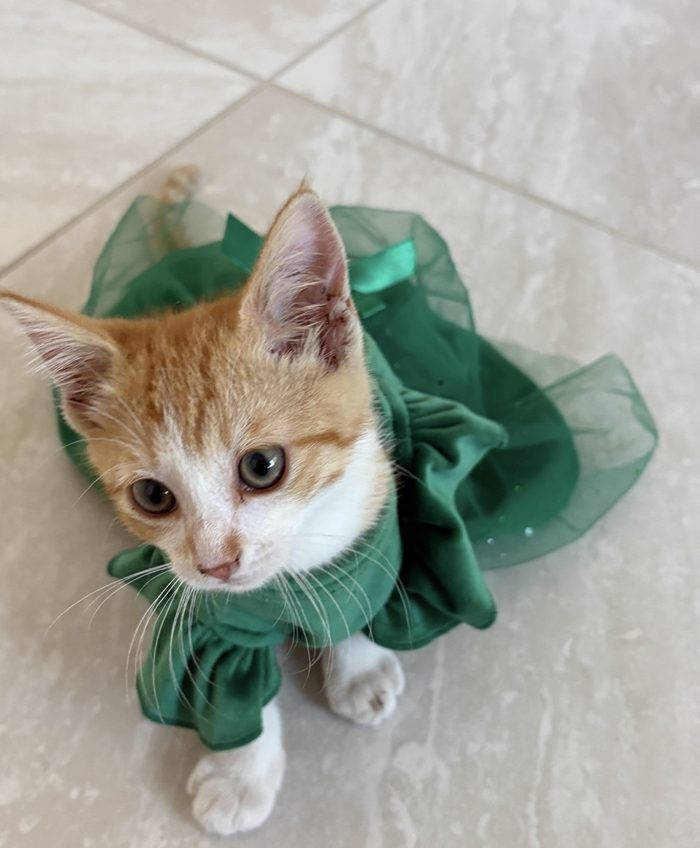
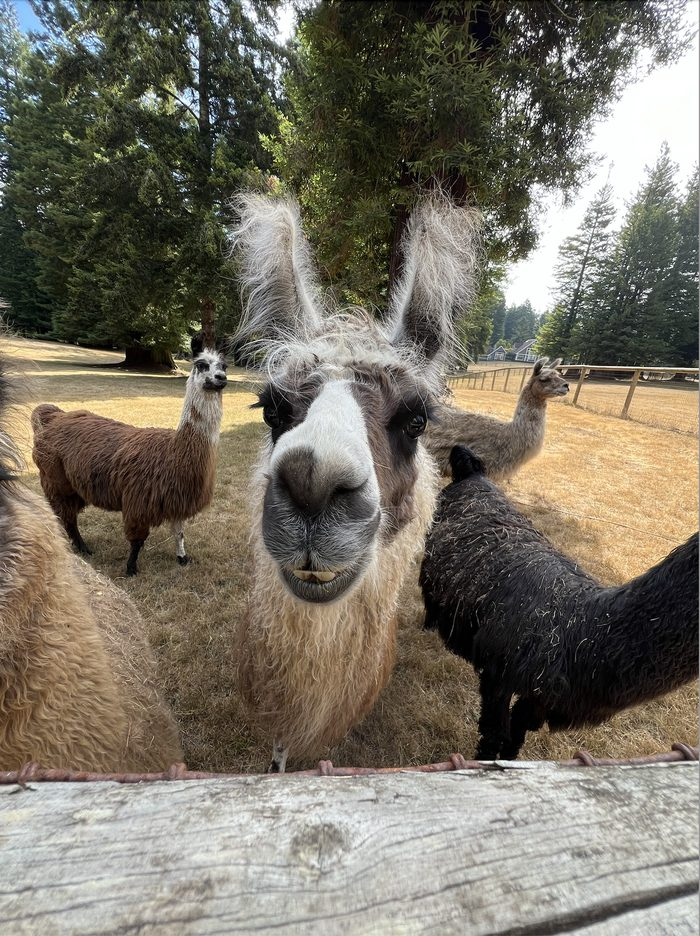
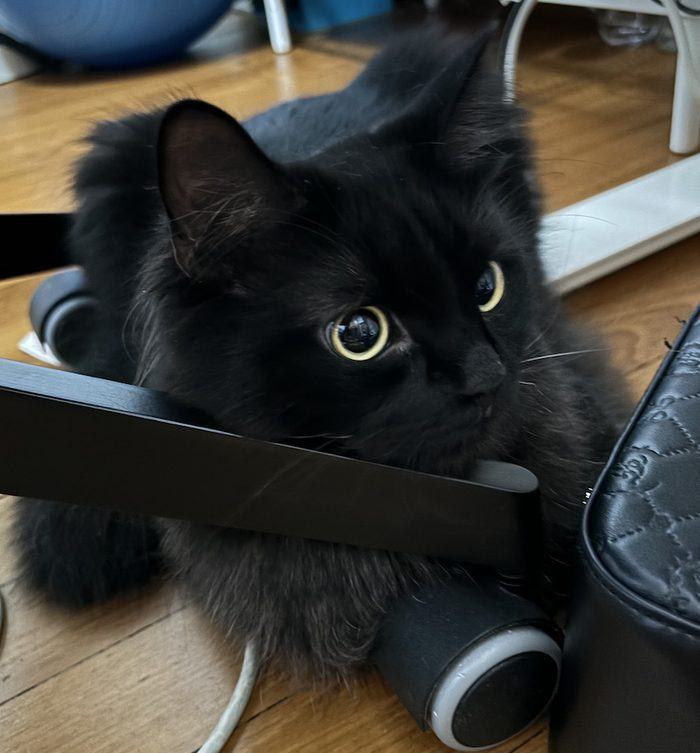

Congrats on finishing Homework 6!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()

### Submission
1. Run `grader.check_all()` above and make sure all tests pass.
2. **File → Download → Download .ipynb**
3. Upload the `.ipynb` file to the LMS.

_(`grader.export()` does not work on Google Colab, so it has been removed.)_